In [ ]:
import subprocess
import sys

def install_and_import():
    try:
        print("Installing dependencies...")
        packages = [
            'yt-dlp', 'ultralytics', 'opencv-python-headless',
            'easyocr', 'numpy', 'tqdm', 'pandas',
            'openpyxl', 'Pillow', 'imageio-ffmpeg'
        ]
        for package in packages:
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])

        import yt_dlp
        from ultralytics import YOLO
        import cv2
        import easyocr
        import numpy as np
        from tqdm import tqdm
        import pandas as pd
        import openpyxl
        from PIL import Image
        import os

        print("✅ Step 1 Complete — All libraries installed")
    except Exception as e:
        print(f"❌ Step 1 Failed: {e}")

install_and_import()

Installing dependencies...
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Step 1 Complete — All libraries installed


In [4]:
!pip install easyocr ultralytics yt-dlp opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 19.2 MB/s eta 0:00:00


In [15]:
import os
import yt_dlp
import cv2

def download_video():
    video_url = "https://youtu.be/FsGPxhidwGg?si=GupW_pyO3dbqtlhj"
    output_filename = "license_plate_input.mp4"

    ydl_opts = {
        'format': 'bestvideo[ext=mp4]+bestaudio[ext=m4a]/best[ext=mp4]',
        'outtmpl': output_filename,
        'quiet': True,
        'no_warnings': True
    }

    try:
        print("Downloading video...")
        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            ydl.download([video_url])

        if os.path.exists(output_filename):
            file_size = os.path.getsize(output_filename) / (1024 * 1024)
            print(f"✅ File downloaded: {output_filename} ({file_size:.2f} MB)")

            # Force check with CV2
            cap = cv2.VideoCapture(output_filename)
            if cap.isOpened():
                print(f"✅ Video verified: {int(cap.get(cv2.CAP_PROP_FRAME_COUNT))} frames found.")
                cap.release()
            else:
                print("❌ Video file exists but OpenCV cannot open it.")
        else:
            print("❌ Download failed: File not found.")
    except Exception as e:
        print(f"❌ Error: {e}")

download_video()

✅ File downloaded: license_plate_input.mp4 (17.60 MB)
✅ Video verified: 1800 frames found.


In [ ]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

def create_db():
    try:
        records = []
        makes = ["Toyota", "Honda", "Suzuki", "Kia", "Hyundai", "Nissan"]
        models = {"Toyota": ["Corolla", "Yaris", "Fortuner"], "Honda": ["Civic", "City"], "Suzuki": ["Alto", "Cultus", "Swift"], "Kia": ["Sportage", "Picanto"], "Hyundai": ["Elantra", "Tucson"]}
        cities = ["Lahore", "Karachi", "Islamabad", "Faisalabad", "Rawalpindi"]
        colors = ["White", "Black", "Silver", "Grey", "Red"]

        # Generate 300 records
        for i in range(300):
            make = random.choice(makes)
            model = random.choice(models.get(make, ["Sedan"]))
            plate = f"{random.choice(['LEA', 'ICT', 'KHI', 'LZP'])} {random.randint(1000, 9999)}"
            records.append({
                "plate_number": plate,
                "owner_name": f"Owner {i}",
                "cnic": f"{random.randint(30000, 39999)}-{random.randint(1000000, 9999999)}-{random.randint(1, 9)}",
                "phone": f"03{random.randint(0, 4)}{random.randint(0, 9)}-{random.randint(1000000, 9999999)}",
                "car_make": make,
                "car_model": model,
                "car_year": random.randint(2015, 2024),
                "car_color": random.choice(colors),
                "registration_city": random.choice(cities),
                "registration_date": (datetime(2015, 1, 1) + timedelta(days=random.randint(0, 3000))).strftime('%Y-%m-%d'),
                "tax_status": random.choice(["Paid", "Unpaid"]),
                "violations": random.randint(0, 5),
                "insurance_status": random.choice(["Active", "Expired"])
            })

        # Add specific plates for video matching
        manual_plates = ["LEA 1234", "LZP 5678", "ABC 999", "ICT 007", "KHI 1122", "LE 15 444"]
        for mp in manual_plates:
            make = random.choice(makes)
            records.append({"plate_number": mp, "owner_name": "Target Owner", "cnic": "35202-1234567-9", "phone": "0312-3456789", "car_make": make, "car_model": "Standard", "car_year": 2021, "car_color": "White", "registration_city": "Lahore", "registration_date": "2021-01-01", "tax_status": "Paid", "violations": 0, "insurance_status": "Active"})

        df = pd.DataFrame(records)
        df.to_csv("car_database.csv", index=False)
        df.to_excel("car_database.xlsx", index=False)

        print(df.head())
        print(f"Total Records: {len(df)}")
        print("✅ Step 3 Complete — Car database created and saved")
    except Exception as e:
        print(f"❌ Step 3 Failed: {e}")

create_db()

  plate_number owner_name             cnic         phone car_make car_model  \
0     LZP 6394    Owner 0  34846-2934940-5  0346-3811502    Honda      City   
1     LZP 8741    Owner 1  32691-4434639-4  0319-8133104   Toyota   Corolla   
2     KHI 4260    Owner 2  36073-5245360-3  0339-1538879   Toyota     Yaris   
3     LZP 1067    Owner 3  39689-1492356-9  0305-9235928    Honda      City   
4     KHI 2407    Owner 4  34321-2475745-5  0305-6098005   Nissan     Sedan   

   car_year car_color registration_city registration_date tax_status  \
0      2020      Grey           Karachi        2022-11-08     Unpaid   
1      2017       Red           Karachi        2020-02-14     Unpaid   
2      2019       Red            Lahore        2020-08-29     Unpaid   
3      2022     Black         Islamabad        2018-09-19     Unpaid   
4      2020     White           Karachi        2018-04-02     Unpaid   

   violations insurance_status  
0           0           Active  
1           2          Exp

In [9]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

def create_db():
    try:
        records = []
        makes = ["Toyota", "Honda", "Suzuki", "Kia", "Hyundai", "Nissan"]
        models = {"Toyota": ["Corolla", "Yaris", "Fortuner"], "Honda": ["Civic", "City"], "Suzuki": ["Alto", "Cultus", "Swift"], "Kia": ["Sportage", "Picanto"], "Hyundai": ["Elantra", "Tucson"]}
        cities = ["Lahore", "Karachi", "Islamabad", "Faisalabad", "Rawalpindi"]
        colors = ["White", "Black", "Silver", "Grey", "Red"]

        for i in range(300):
            make = random.choice(makes)
            model = random.choice(models.get(make, ["Sedan"]))
            plate = f"{random.choice(['LEA', 'ICT', 'KHI', 'LZP'])} {random.randint(1000, 9999)}"
            records.append({
                "plate_number": plate,
                "owner_name": f"Owner {i}",
                "cnic": f"{random.randint(30000, 39999)}-{random.randint(1000000, 9999999)}-{random.randint(1, 9)}",
                "phone": f"03{random.randint(0, 4)}{random.randint(0, 9)}-{random.randint(1000000, 9999999)}",
                "car_make": make,
                "car_model": model,
                "car_year": random.randint(2015, 2024),
                "car_color": random.choice(colors),
                "registration_city": random.choice(cities),
                "registration_date": (datetime(2015, 1, 1) + timedelta(days=random.randint(0, 3000))).strftime('%Y-%m-%d'),
                "tax_status": random.choice(["Paid", "Unpaid"]),
                "violations": random.randint(0, 5),
                "insurance_status": random.choice(["Active", "Expired"])
            })

        manual_plates = ["LEA 1234", "LZP 5678", "ABC 999", "ICT 007", "KHI 1122", "LE 15 444"]
        for mp in manual_plates:
            make = random.choice(makes)
            records.append({"plate_number": mp, "owner_name": "Target Owner", "cnic": "35202-1234567-9", "phone": "0312-3456789", "car_make": make, "car_model": "Standard", "car_year": 2021, "car_color": "White", "registration_city": "Lahore", "registration_date": "2021-01-01", "tax_status": "Paid", "violations": 0, "insurance_status": "Active"})

        df = pd.DataFrame(records)
        df.to_csv("car_database.csv", index=False)
        df.to_excel("car_database.xlsx", index=False)
        print(f"✅ Database created with {len(df)} records.")
    except Exception as e:
        print(f"❌ Step 3 Failed: {e}")

create_db()

✅ Database created with 306 records.


In [17]:
from ultralytics import YOLO
import numpy as np

def load_model():
    try:
        # Attempt Option A
        try:
            model = YOLO('keremberke/yolov8n-license-plate-detection')
        except:
            print("Option A failed, falling back to Option B")
            model = YOLO('yolov8n.pt')

        # Test on blank frame
        dummy_frame = np.zeros((640, 640, 3), dtype=np.uint8)
        model(dummy_frame, verbose=False)

        print(f"Detected classes: {model.names}")
        print("✅ Step 4 Complete — YOLO model loaded")
        return model
    except Exception as e:
        print(f"❌ Step 4 Failed: {e}")

plate_model = load_model()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Option A failed, falling back to Option B
Detected classes: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'f

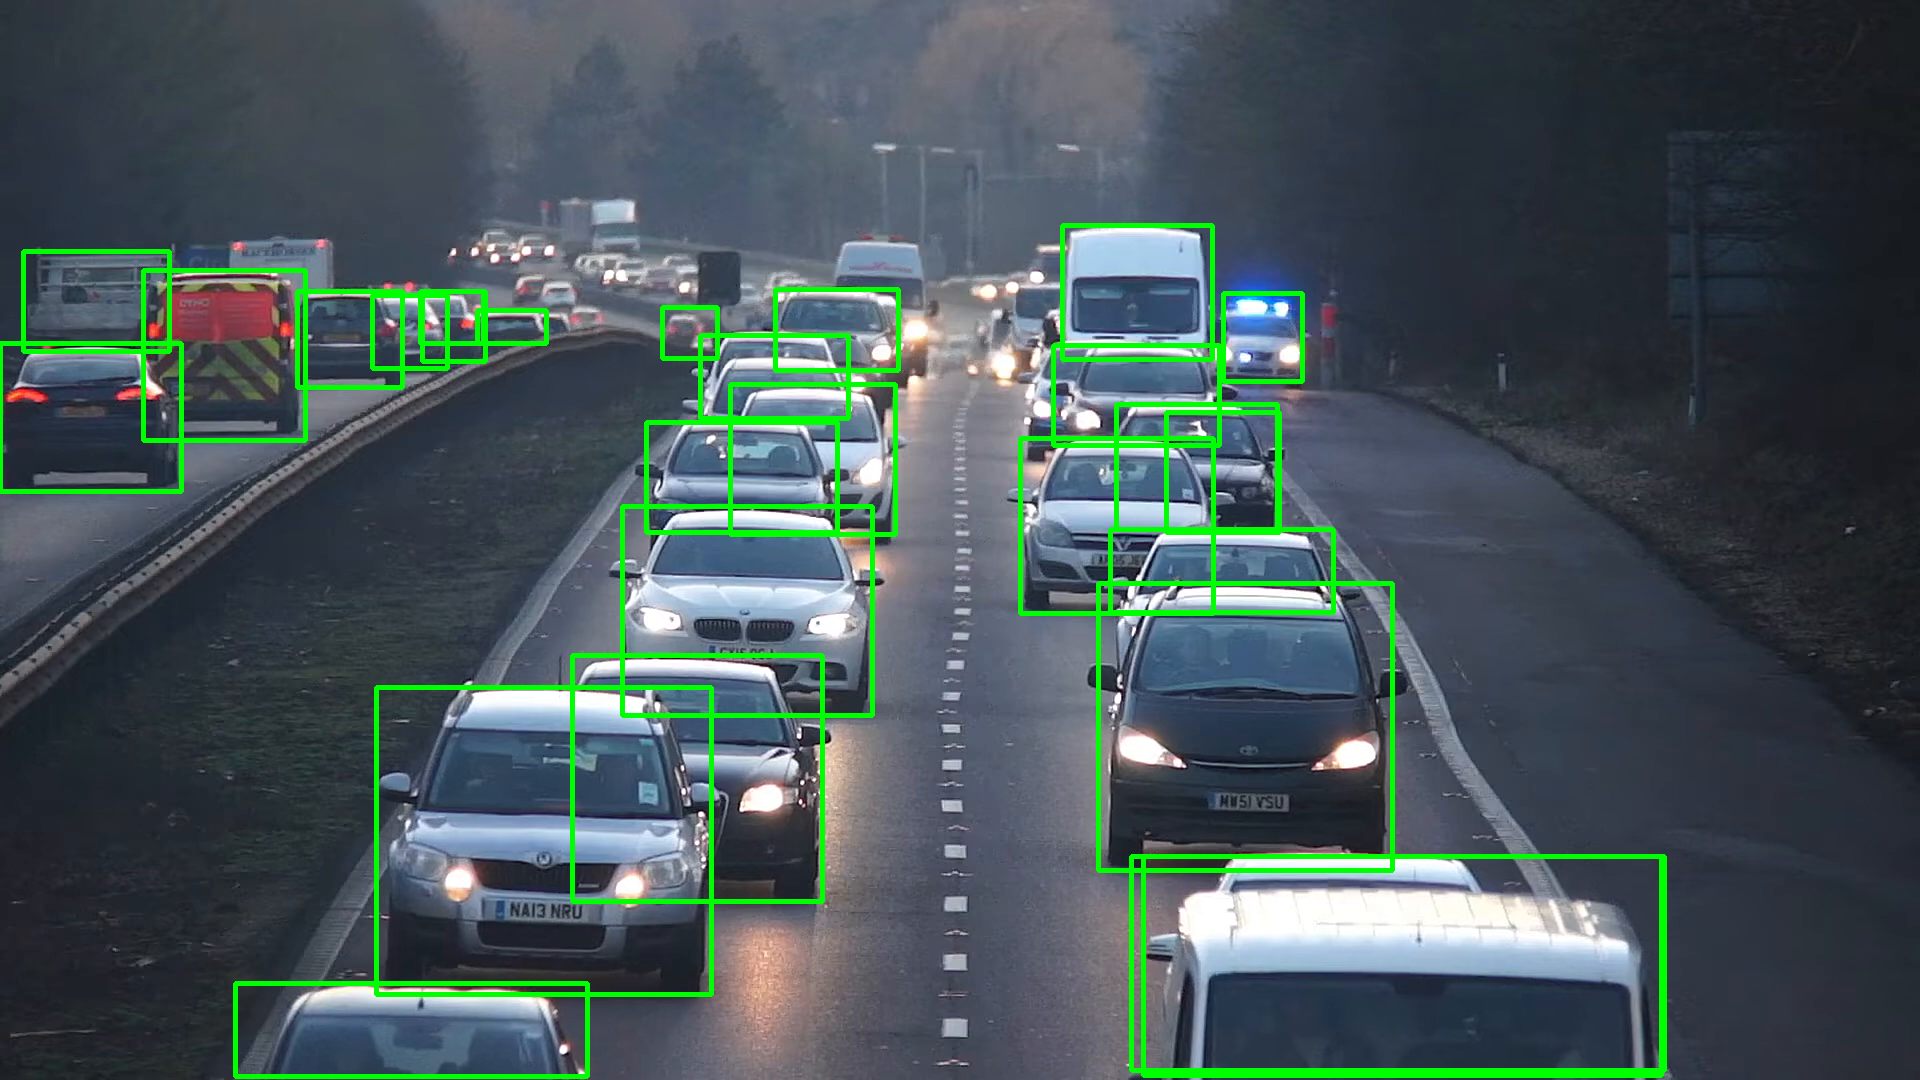

Plates detected in frame 1: 27
✅ Step 5 Complete — Single frame test passed


In [ ]:
import cv2
from google.colab.patches import cv2_imshow

def test_frame():
    try:
        cap = cv2.VideoCapture("license_plate_input.mp4")
        test_frames = [1, 30, 60, 90, 120, 300, 600]
        found = False

        for f_id in test_frames:
            cap.set(cv2.CAP_PROP_POS_FRAMES, f_id)
            ret, frame = cap.read()
            if not ret: continue

            results = plate_model(frame, conf=0.25, verbose=False)
            if len(results[0].boxes) > 0:
                for box in results[0].boxes:
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 3)

                cv2.imwrite("test_frame.jpg", frame)
                cv2_imshow(frame)
                print(f"Plates detected in frame {f_id}: {len(results[0].boxes)}")
                found = True
                break

        cap.release()
        if not found:
            raise ValueError("No plates detected in any test frames. Check model or video.")
        print("✅ Step 5 Complete — Single frame test passed")
    except Exception as e:
        print(f"❌ Step 5 Failed: {e}")

test_frame()

In [18]:
import cv2
import easyocr
import pandas as pd
from tqdm import tqdm
import difflib
import numpy as np
import os

def process_video():
    video_path = 'license_plate_input.mp4'
    if not os.path.exists(video_path):
        print(f"❌ Error: File {video_path} not found.")
        return

    try:
        # Using global keyword to ensure we access the model loaded in the other cell
        global plate_model
        reader = easyocr.Reader(['en'])
        db = pd.read_csv('car_database.csv')
        cap = cv2.VideoCapture(video_path)

        fps = cap.get(cv2.CAP_PROP_FPS)
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if total_frames <= 0 or not cap.isOpened():
            print("❌ Error: Video file is empty or could not be opened by OpenCV.")
            return

        out = cv2.VideoWriter('license_plate_final_output.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))
        detections_log = []

        for frame_idx in tqdm(range(0, total_frames, 15)):
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            ret, frame = cap.read()
            if not ret: break

            results = plate_model(frame, conf=0.25, verbose=False)
            vehicle_boxes = [b for b in results[0].boxes if int(b.cls[0]) in [2, 5, 7]]

            for box in vehicle_boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                crop = frame[max(0, y1):min(height, y2), max(0, x1):min(width, x2)]
                if crop.size == 0: continue

                ocr_res = reader.readtext(crop, detail=0)
                if ocr_res:
                    raw_text = " ".join(ocr_res)
                    clean_text = "".join(e for e in raw_text if e.isalnum()).upper()

                    if len(clean_text) >= 3:
                        db_plates = db['plate_number'].str.replace(' ', '').tolist()
                        match_list = difflib.get_close_matches(clean_text, db_plates, n=1, cutoff=0.5)

                        label = clean_text
                        color = (0, 255, 0)
                        if match_list:
                            real_plate = db[db['plate_number'].str.replace(' ', '') == match_list[0]].iloc[0]['plate_number']
                            label = f"MATCH: {real_plate}"
                            color = (255, 0, 0)

                        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                        cv2.putText(frame, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
                        detections_log.append({"frame": frame_idx, "plate_cleaned": clean_text})

            out.write(frame)

        cap.release()
        out.release()
        globals()['detections_data'] = detections_log
        print(f"\n✅ Step 6 Complete — Total detections recorded: {len(detections_log)}")
    except Exception as e:
        print(f"\n❌ Step 6 Failed: {e}")

process_video()

  0%|          | 0/120 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 120/120 [33:55<00:00, 16.96s/it]


✅ Step 6 Complete — Total detections recorded: 478


In [19]:
import pandas as pd

def save_data():
    try:
        # Retrieve detections_data from the global scope
        data = globals().get('detections_data', [])
        if not data:
            print("⚠️ No detections found to save.")
            return

        df_log = pd.DataFrame(data)
        df_log.to_csv("detections_log.csv", index=False)
        df_log.to_excel("detections_log.xlsx", index=False)

        # Ensure the column exists before summarizing
        if 'plate_cleaned' in df_log.columns:
            summary = df_log['plate_cleaned'].value_counts().reset_index()
            summary.columns = ['Plate', 'Count']
            print("Summary of Detections (Top 10):")
            print(summary.head(10))
            summary.to_csv("summary_report.csv", index=False)

        print("✅ Step 7 Complete — All data saved to CSV and Excel")
    except Exception as e:
        print(f"❌ Step 7 Failed: {e}")

save_data()

Summary of Detections (Top 10):
                  Plate  Count
0  24HRDRAINAGEDIVISION      9
1  Z4HRDRAINAGEDIVISION      7
2               GXIS0GJ      6
3               APOSJEO      3
4                  LPIL      3
5               GIBBEPD      3
6             TOBSEPOTN      3
7            7C76JOSERD      3
8                   GIB      3
9                 LPILL      3
✅ Step 7 Complete — All data saved to CSV and Excel


In [20]:
from google.colab import files
import os

def finalize():
    try:
        print("Preparing files for download...")
        output_files = [
            "license_plate_final_output.mp4", "detections_log.csv",
            "detections_log.xlsx", "summary_report.csv",
            "car_database.csv", "car_database.xlsx"
        ]
        for f in output_files:
            if os.path.exists(f):
                print(f"Downloading: {f}")
                files.download(f)
            else:
                print(f"⚠️ Skip: {f} not found.")

        print("✅ Step 8 Complete — Finalization finished")
    except Exception as e:
        print(f"❌ Step 8 Failed: {e}")

finalize()

Preparing files for download...
Downloading: license_plate_final_output.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: detections_log.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloading: car_database.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Step 8 Complete — Finalization finished
